# Jaguar Re-Identification - ResNet-34 Improved

Améliorations par rapport au ResNet-34 baseline (notebook 06) :
1. **Architecture corrigée** : ReLU + BatchNorm (au lieu de tanh sans normalisation)
2. **Régularisation** : AdamW (weight decay 1e-4) + Dropout(0.4)
3. **Plus d'epochs** : 100 epochs, EarlyStopping patience=20, ReduceLROnPlateau

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import normalize

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1773417131.560209   52877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773417131.722767   52877 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773417133.146277   52877 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1773417134.525573   52877 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR = os.path.join(DATA_DIR, 'cleaned')
TRAIN_IMG_DIR = os.path.join(CLEANED_DIR, 'train')
TEST_IMG_DIR = os.path.join(CLEANED_DIR, 'test')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR = r'C:\tf\logs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Data loading

In [3]:
train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(CLEANED_DIR, 'val_split.csv'))
test_pairs_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

print(f"Train: {len(train_df)} images")
print(f"Val:   {len(val_df)} images")
print(f"Test pairs: {len(test_pairs_df)}")

Train: 1516 images
Val:   379 images
Test pairs: 137270


In [4]:
def load_images_from_df(df, img_dir):
    images, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(os.path.join(img_dir, row['filename'])).convert('RGB')
        images.append(np.array(img, dtype=np.float32) / 255.0)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

def load_test_images(img_dir):
    test_images = {}
    for fname in sorted(os.listdir(img_dir)):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
            test_images[fname] = np.array(img, dtype=np.float32) / 255.0
    return test_images

print("Loading images...")
X_train, y_train = load_images_from_df(train_df, TRAIN_IMG_DIR)
X_val, y_val = load_images_from_df(val_df, TRAIN_IMG_DIR)
test_images = load_test_images(TEST_IMG_DIR)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, test: {len(test_images)}")

Loading images...
X_train: (1516, 224, 224, 3), X_val: (379, 224, 224, 3), test: 371


## 2. ResNet-34 architecture (corrected)

Corrections vs notebook 06 :
- Conv → **BatchNorm → ReLU** (au lieu de Conv → tanh)
- Shortcut projection : Conv1x1 → **BatchNorm**
- **Dropout(0.4)** avant la couche de classification

In [5]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x


def create_resnet34(input_shape, num_classes):
    inputs = keras.Input(input_shape)

    # Initial conv + pool
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

resnet = create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
resnet.summary()

W0000 00:00:1773417139.056980   52877 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773417139.217589   52877 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5035 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 21,317,599 (81.32 MB)

 Trainable params: 21,300,575 (81.26 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. Training

In [6]:
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 100

resnet.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_log_dir = os.path.join(LOG_DIR, 'resnet34_improved', datetime.now().strftime('%Y%m%d-%H%M%S'))

resnet_history = resnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.TensorBoard(log_dir=resnet_log_dir, histogram_freq=1),
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1773417149.651586   53078 service.cc:153] XLA service 0x7f10d407c3e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773417149.651676   53078 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773417149.856882   53078 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773417151.813972   53078 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1773417152.076710   53078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23991__.238


 2/48 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.0000e+00 - loss: 5.3789  

I0000 00:00:1773417163.360482   53078 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0934 - loss: 4.3197

I0000 00:00:1773417166.634952   53080 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23991__.238


48/48 ━━━━━━━━━━━━━━━━━━━━ 34s 300ms/step - accuracy: 0.1398 - loss: 3.7404 - val_accuracy: 0.0211 - val_loss: 117.0118 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.2935 - loss: 2.6533 - val_accuracy: 0.0079 - val_loss: 437.4200 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.4189 - loss: 2.1017 - val_accuracy: 0.0132 - val_loss: 19.1658 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.4782 - loss: 1.9124 - val_accuracy: 0.1029 - val_loss: 15.5981 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5798 - loss: 1.5142 - val_accuracy: 0.1266 - val_loss: 6.7077 - learning_rate: 0.0010
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.6207 - loss: 1.3889 - val_accuracy: 0.3694 - val_loss: 3.2676 - learning_rate: 0.0010
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.6669 - loss: 1.2128 - val_

In [7]:
train_loss, train_acc = resnet.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = resnet.evaluate(X_val, y_val, verbose=0)

print(f"ResNet-34 improved:")
print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
print(f"\nvs ResNet-34 baseline (notebook 06):")
print(f"  Train - Loss: 0.3914, Acc: 0.9037")
print(f"  Val   - Loss: 0.9792, Acc: 0.8100")

ResNet-34 improved:
  Train - Loss: 0.0003, Acc: 1.0000
  Val   - Loss: 0.7877, Acc: 0.8602

vs ResNet-34 baseline (notebook 06):
  Train - Loss: 0.3914, Acc: 0.9037
  Val   - Loss: 0.9792, Acc: 0.8100


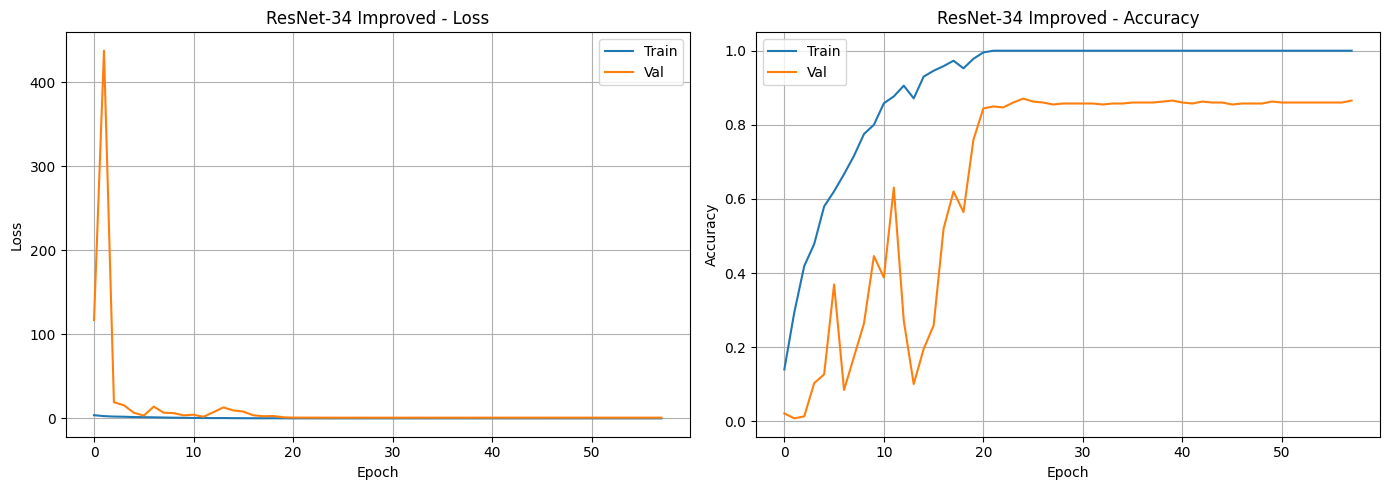

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resnet_history.history['loss'], label='Train')
axes[0].plot(resnet_history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ResNet-34 Improved - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(resnet_history.history['accuracy'], label='Train')
axes[1].plot(resnet_history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('ResNet-34 Improved - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'resnet34_improved_history.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Submission

In [9]:
final_resnet = create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES)
final_resnet.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

all_train_df = pd.read_csv(os.path.join(CLEANED_DIR, 'train_clean.csv'))
X_all, y_all = load_images_from_df(all_train_df, TRAIN_IMG_DIR)

best_epoch = np.argmin(resnet_history.history['val_loss']) + 1
print(f"Best epoch from val: {best_epoch}")

final_resnet.fit(
    X_all, y_all,
    epochs=best_epoch,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.ReduceLROnPlateau(
            monitor='loss',
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1
        )
    ],
    verbose=1
)

print(f"Final train accuracy: {final_resnet.evaluate(X_all, y_all, verbose=0)[1]:.4f}")

Best epoch from val: 38
Epoch 1/38


I0000 00:00:1773417382.709829   53078 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1535412__.238


59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1181 - loss: 3.9595

I0000 00:00:1773417389.924360   53077 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1535412__.238


60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 197ms/step - accuracy: 0.1757 - loss: 3.4506 - learning_rate: 0.0010
Epoch 2/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.3277 - loss: 2.4858 - learning_rate: 0.0010
Epoch 3/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4354 - loss: 2.0349 - learning_rate: 0.0010
Epoch 4/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5129 - loss: 1.7687 - learning_rate: 0.0010
Epoch 5/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5984 - loss: 1.4532 - learning_rate: 0.0010
Epoch 6/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6686 - loss: 1.1552 - learning_rate: 0.0010
Epoch 7/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7150 - loss: 1.0002 - learning_rate: 0.0010
Epoch 8/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7615 - loss: 0.8356 - learning_rate: 0.0010
Epoch 9/38
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7942 - loss: 0.6793 - learning_rate: 0.0010
Epoch 10/38
60/60 ━━━━━━━━━━

I0000 00:00:1773417485.209879   61886 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 16 bytes spill stores, 16 bytes spill loads



Final train accuracy: 1.0000


In [10]:
embedding_model = keras.Model(
    inputs=final_resnet.input,
    outputs=final_resnet.layers[-2].output
)

test_filenames = sorted(test_images.keys())
test_array = np.array([test_images[f] for f in test_filenames])

test_embeddings = embedding_model.predict(test_array, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embeddings shape: {test_embeddings.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step
Embeddings shape: (371, 512)


In [11]:
query_idx = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.sum(
    test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx],
    axis=1
)
similarities = np.clip(similarities, 0, 1)

print(f"Similarities: {len(similarities)} pairs")
print(f"Min: {similarities.min():.4f}, Max: {similarities.max():.4f}, Mean: {similarities.mean():.4f}")

Similarities: 137270 pairs
Min: 0.2586, Max: 0.9998, Mean: 0.6171


In [12]:
submission = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

submission_path = os.path.join(SUBMISSION_DIR, 'submission_resnet34_improved.csv')
submission.to_csv(submission_path, index=False)

print(f"Saved: {submission_path}")
display(submission.head(10))

sample_sub = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)

Saved: /home/franck/jaguar/submissions/submission_resnet34_improved.csv


,row_id,similarity
0,0,0.873388
1,1,0.733406
2,2,0.715889
3,3,0.682559
4,4,0.711474
5,5,0.567177
6,6,0.607518
7,7,0.708597
8,8,0.598969
9,9,0.790262


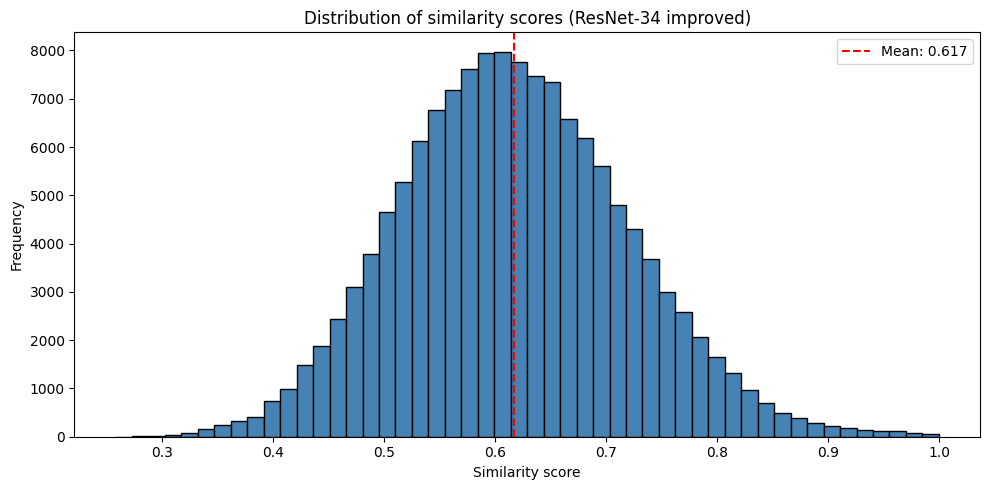

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Similarity score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of similarity scores (ResNet-34 improved)')
ax.axvline(x=similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_distribution_resnet34_improved.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

In [14]:
print(f"""
ResNet-34 improved:
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Best epoch: {best_epoch}
  Embedding dim: {test_embeddings.shape[1]}
  Regularisation: AdamW (wd={WEIGHT_DECAY}), Dropout(0.4)

vs ResNet-34 baseline (notebook 06):
  Train: 0.9037, Val: 0.8100
  (tanh, pas de BN, pas de regularisation, 50 epochs)

Submission -> {submission_path}
""")


ResNet-34 improved:
  Train - Loss: 0.0003, Acc: 1.0000
  Val   - Loss: 0.7877, Acc: 0.8602
  Best epoch: 38
  Embedding dim: 512
  Regularisation: AdamW (wd=0.0001), Dropout(0.4)

vs ResNet-34 baseline (notebook 06):
  Train: 0.9037, Val: 0.8100
  (tanh, pas de BN, pas de regularisation, 50 epochs)

Submission -> /home/franck/jaguar/submissions/submission_resnet34_improved.csv

